Exception in Tkinter callback
Traceback (most recent call last):
  File "c:\Users\nitan\anaconda3\Lib\tkinter\__init__.py", line 1948, in __call__
    return self.func(*args)
           ^^^^^^^^^^^^^^^^
  File "c:\Users\nitan\anaconda3\Lib\site-packages\customtkinter\windows\widgets\ctk_checkbox.py", line 423, in toggle
    self._command()
  File "C:\Users\nitan\AppData\Local\Temp\ipykernel_31352\2600510583.py", line 960, in on_baseline
    self._render_offline_plot()
  File "C:\Users\nitan\AppData\Local\Temp\ipykernel_31352\2600510583.py", line 789, in _render_offline_plot
    s1p, s2p = self._apply_processing(t, s1, s2)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\nitan\AppData\Local\Temp\ipykernel_31352\2600510583.py", line 744, in _apply_processing
    base1 = self._baseline_asls(s1p, lam=1e5, p=0.01, niter=10)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\nitan\AppData\Local\Temp\ipykernel_31352\2600510583.py", line 717, in _

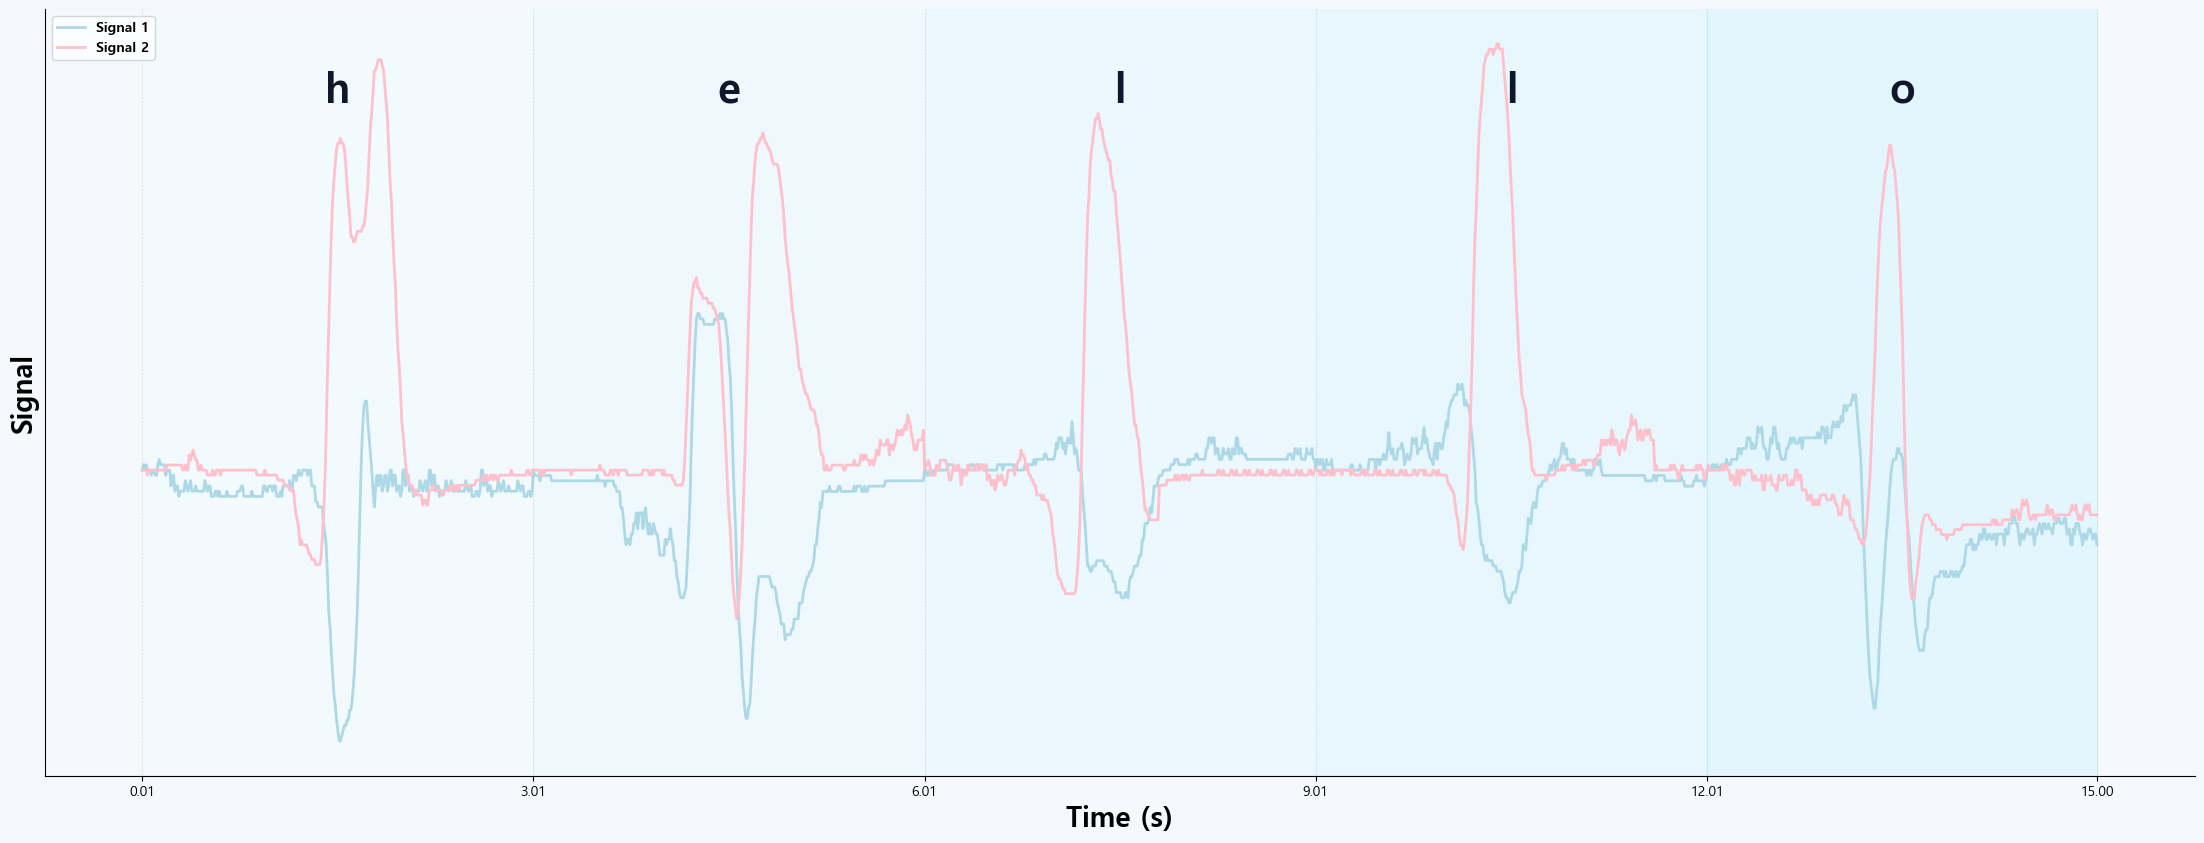

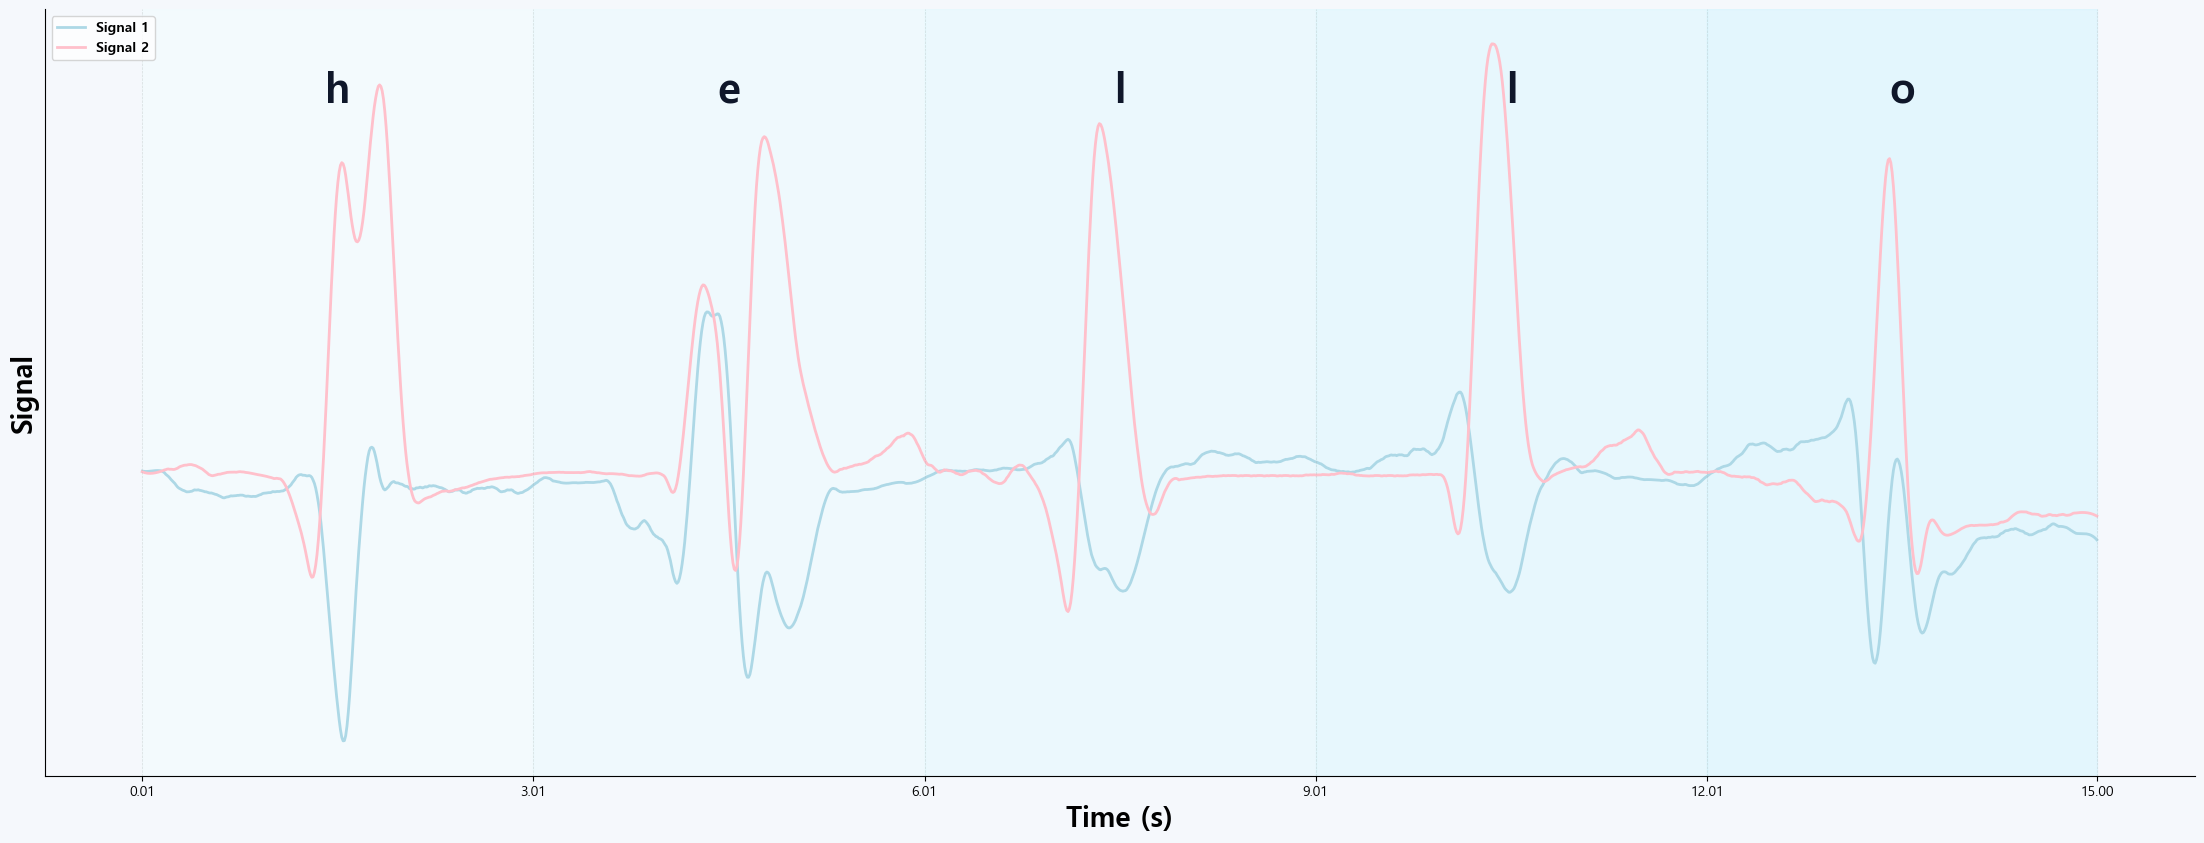

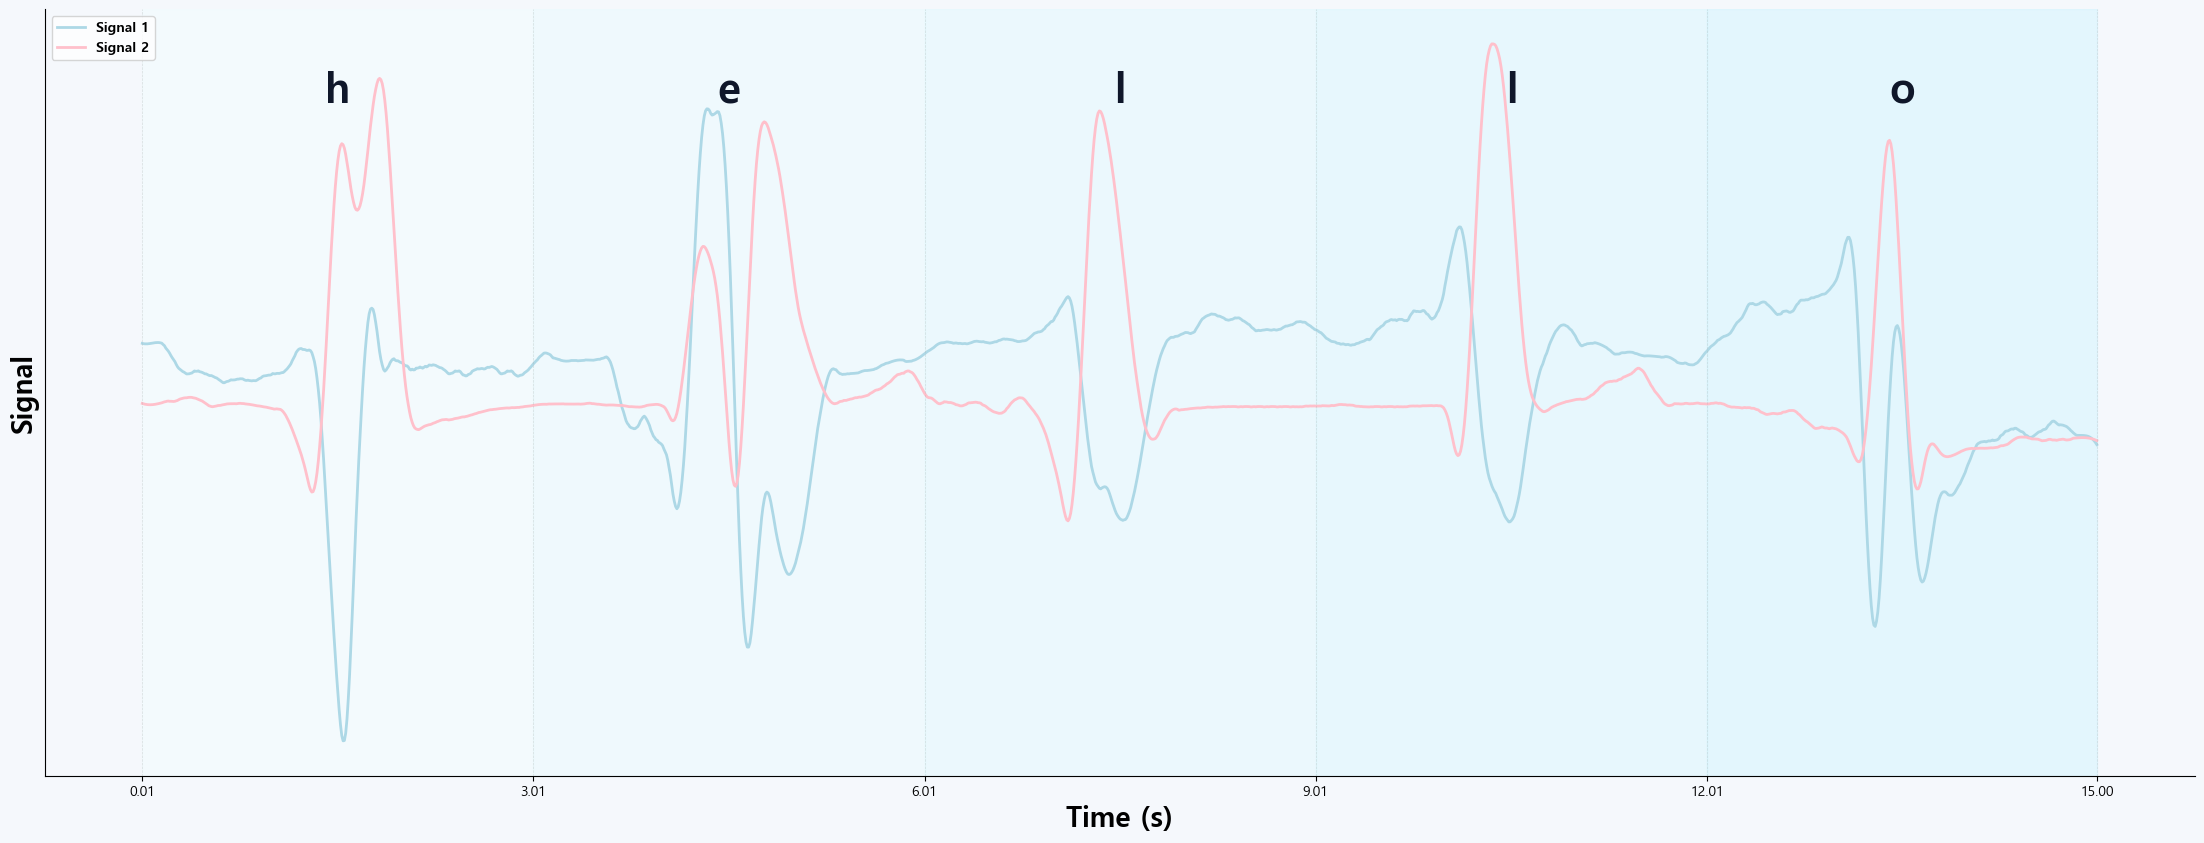

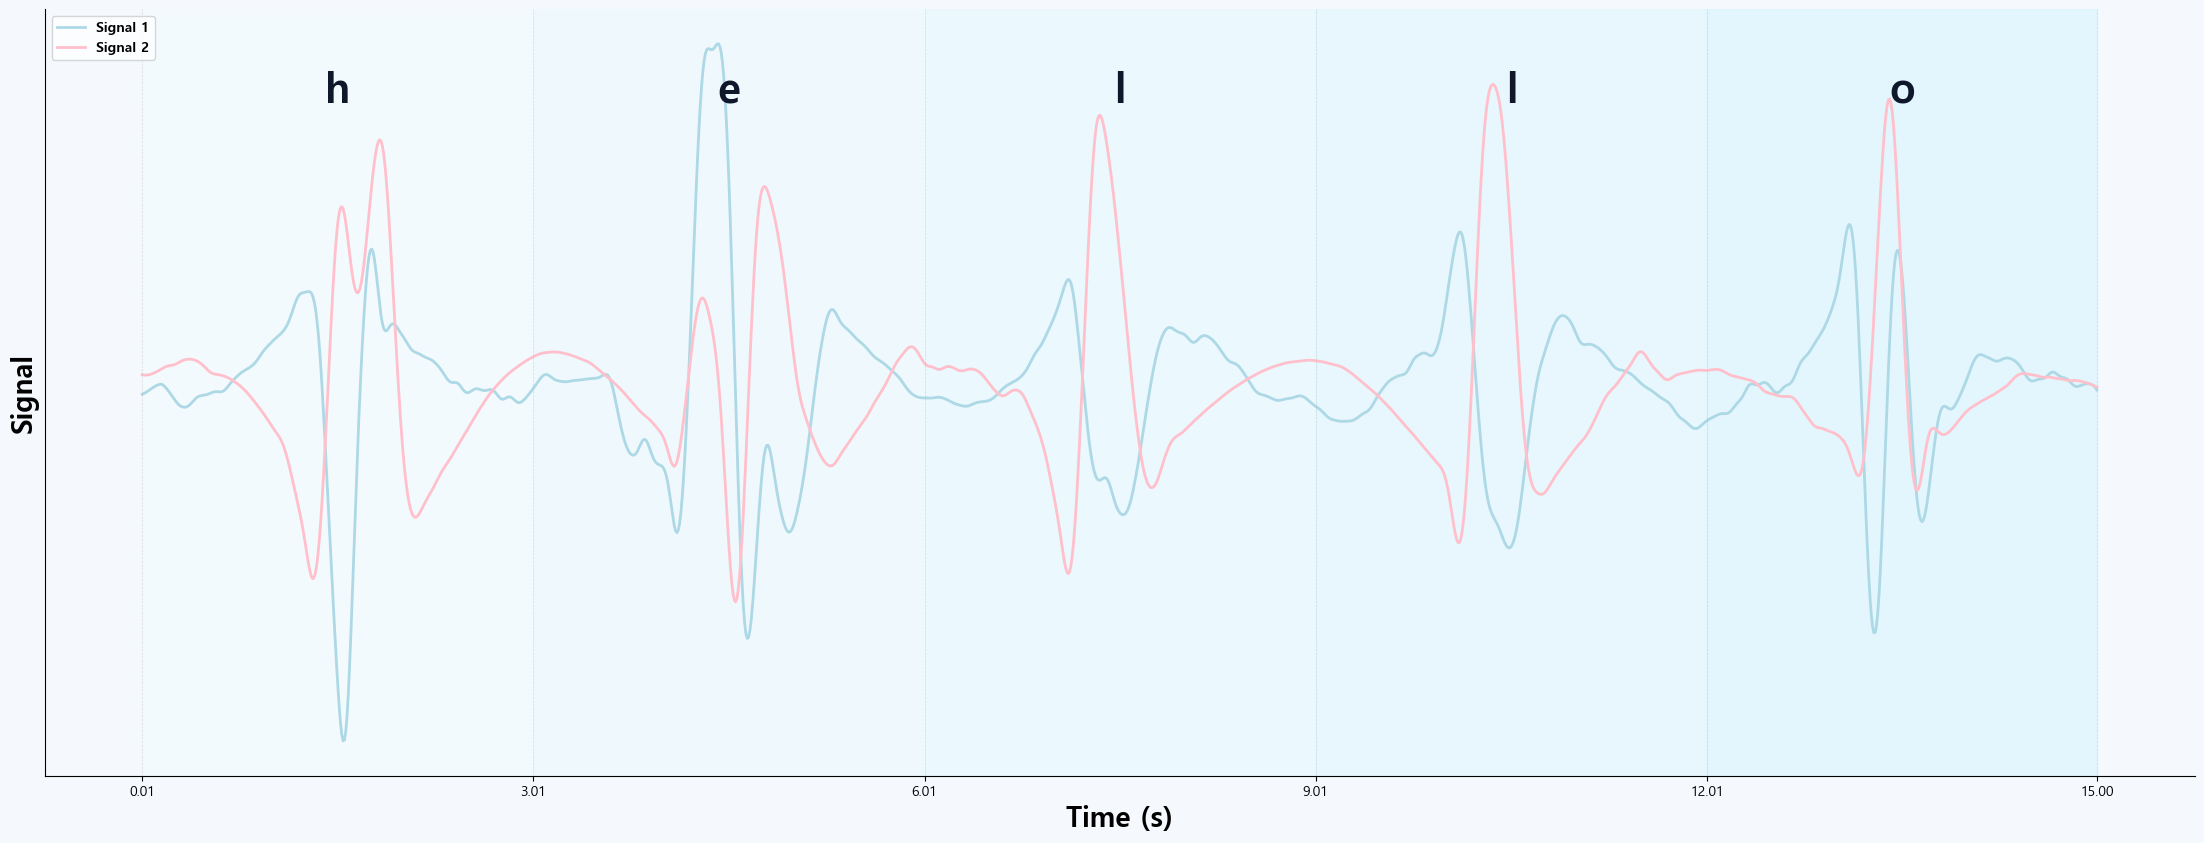

In [ ]:
# GUI
import customtkinter as ctk
import tkinter as tk
from tkinter import filedialog, messagebox
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from matplotlib import rcParams
import numpy as np
import os
import re
from PIL import Image, ImageTk
from scipy.signal import savgol_filter, butter, filtfilt
from deep_translator import GoogleTranslator


# ================== FONT HELPER ==================
def set_font_by_language_hint(filename: str):
    f = filename.lower()
    if any(lang in f for lang in ['korean', 'english']):
        rcParams['font.family'] = 'Malgun Gothic'
    elif any(lang in f for lang in ['japanese', 'chinese']):
        rcParams['font.family'] = 'Microsoft YaHei'
    else:
        rcParams['font.family'] = 'Segoe UI'


# List jamo awal (L), vokal (V), dan final (T) untuk komposisi Hangul
L_LIST = ['ㄱ','ㄲ','ㄴ','ㄷ','ㄸ','ㄹ','ㅁ','ㅂ','ㅃ','ㅅ','ㅆ','ㅇ','ㅈ','ㅉ','ㅊ','ㅋ','ㅌ','ㅍ','ㅎ']
V_LIST = ['ㅏ','ㅐ','ㅑ','ㅒ','ㅓ','ㅔ','ㅕ','ㅖ','ㅗ','ㅘ','ㅙ','ㅚ','ㅛ','ㅜ','ㅝ','ㅞ','ㅟ','ㅠ','ㅡ','ㅢ','ㅣ']
T_LIST = ['', 'ㄱ','ㄲ','ㄳ','ㄴ','ㄵ','ㄶ','ㄷ','ㄹ','ㄺ','ㄻ','ㄼ','ㄽ','ㄾ','ㄿ','ㅀ','ㅁ','ㅂ','ㅄ','ㅅ','ㅆ','ㅇ','ㅈ','ㅊ','ㅋ','ㅌ','ㅍ','ㅎ']

COMPOSE_V = {
    ('ㅗ','ㅏ'):'ㅘ', ('ㅗ','ㅐ'):'ㅙ', ('ㅗ','ㅣ'):'ㅚ',
    ('ㅜ','ㅓ'):'ㅝ', ('ㅜ','ㅔ'):'ㅞ', ('ㅜ','ㅣ'):'ㅟ',
    ('ㅡ','ㅣ'):'ㅢ'
}

JONG_PAIR = {
    ('ㄱ','ㅅ'):'ㄳ', ('ㄴ','ㅈ'):'ㄵ', ('ㄴ','ㅎ'):'ㄶ',
    ('ㄹ','ㄱ'):'ㄺ', ('ㄹ','ㅁ'):'ㄻ', ('ㄹ','ㅂ'):'ㄼ',
    ('ㄹ','ㅅ'):'ㄽ', ('ㄹ','ㅌ'):'ㄾ', ('ㄹ','ㅍ'):'ㄿ',
    ('ㄹ','ㅎ'):'ㅀ', ('ㅂ','ㅅ'):'ㅄ', ('ㅅ','ㅅ'):'ㅆ'
}


def _compose_code(L, V, T=''):
    L_idx = L_LIST.index(L)
    V_idx = V_LIST.index(V)
    T_idx = T_LIST.index(T)
    return chr(0xAC00 + ((L_idx * 21) + V_idx) * 28 + T_idx)


def compose_hangul_from_jamo(jamo_seq):
    out, i, n = [], 0, len(jamo_seq)
    while i < n:
        L = jamo_seq[i]
        if L not in L_LIST:
            out.append(L)
            i += 1
            continue

        # cek vokal (V)
        if i + 2 < n and (jamo_seq[i+1], jamo_seq[i+2]) in COMPOSE_V:
            V = COMPOSE_V[(jamo_seq[i+1], jamo_seq[i+2])]
            j = i + 3
        elif i + 1 < n and jamo_seq[i+1] in V_LIST:
            V = jamo_seq[i+1]
            j = i + 2
        else:
            out.append(L)
            i += 1
            continue

        # cek batchim (T)
        T = ''
        if j < n:
            c1 = jamo_seq[j]
            if (j+1 < n and jamo_seq[j+1] in L_LIST) and (j+2 < n and jamo_seq[j+2] in V_LIST):
                if c1 in T_LIST[1:]:
                    T = c1
                    j += 1
            elif j+1 < n and (c1, jamo_seq[j+1]) in JONG_PAIR and not (j+2 < n and jamo_seq[j+2] in V_LIST):
                T = JONG_PAIR[(c1, jamo_seq[j+1])]
                j += 2
            elif c1 in T_LIST[1:] and not (j+1 < n and jamo_seq[j+1] in V_LIST):
                T = c1
                j += 1

        out.append(_compose_code(L, V, T))
        i = j
    return ''.join(out)


def _is_precomposed_hangul(ch):
    return len(ch) == 1 and 0xAC00 <= ord(ch) <= 0xD7A3


def build_word_from_segments(segments):
    labs = [str(s['label']).strip() for s in segments if str(s['label']).strip()]
    if labs and all(_is_precomposed_hangul(x) for x in labs):
        return ''.join(labs)
    if labs and all((x in L_LIST or x in V_LIST or x in T_LIST) for x in labs):
        return compose_hangul_from_jamo(labs)
    return compose_hangul_from_jamo(labs)

def _odd_wlen(n, cap=31):
    if n < 3:
        return 3
    w = min(cap, n if n % 2 == 1 else n - 1)
    if w < 3:
        w = 3
    if w % 2 == 0:
        w -= 1
    return w

def _safe_bandpass(x2d, fs, lowcut=0.5, highcut=10.0, order=4):
    x2d = np.asarray(x2d, float)
    if x2d.ndim == 1:
        x2d = x2d[:, None]
    n = x2d.shape[0]
    nyq = 0.5 * float(fs)

    # normalisasi frekuensi cut-off (0 < Wn < 1)
    low = max(1e-6, min(lowcut / nyq, 0.99))
    high = max(low + 1e-6, min(highcut / nyq, 0.999))
    if not (0 < low < high < 1):
        return x2d 

    b, a = butter(order, [low, high], btype='band')
    padlen = 3 * max(len(a), len(b))
    if n <= padlen:
        return x2d 

    try:
        return filtfilt(b, a, x2d, axis=0)
    except Exception:
        return x2d


# ================== MAIN APP CLASS (OFFLINE ONLY) ==================
class HandwritingViewer:

    def __init__(self, root):
        self.root = root
        self.root.title("Smart Teaching - Air Handwriting")
        self.root.minsize(800, 400)
        self.root.geometry("1400x800")

        ctk.set_appearance_mode("light")
        ctk.set_default_color_theme("blue")
        self.root.configure(fg_color="#F5F8FC")

        self.root.grid_rowconfigure(0, weight=0)
        self.root.grid_rowconfigure(1, weight=1)
        self.root.grid_columnconfigure(0, weight=0)
        self.root.grid_columnconfigure(1, weight=1)

        # ---------- STATE UMUM ----------
        self.filename = None
        self.df = None

        # CNN model & label (opsional, untuk offline)
        self.cnn_model = None  
        self.class_labels = []
        self.pred_window = 200 

        # Variabel tampilan output/prediksi
        self.current_class_var = tk.StringVar(value=" ")
        self.current_prob_var  = tk.StringVar(value=" ")
        self.accuracy_var      = tk.StringVar(value=" ")

        # Opsi segmen & signal processing offline
        self.seg_duration_var = tk.StringVar(value="3")
        self.smooth_var       = tk.BooleanVar(value=False)
        self.normalize_var    = tk.BooleanVar(value=False)
        self.filter_var       = tk.BooleanVar(value=False)
        self.baseline_var     = tk.BooleanVar(value=False)

        # State untuk pipeline offline
        self.data_raw  = None
        self.data_proc = None
        self.bp_order  = 4
        self.bp_fs     = 100.0
        self.bp_low    = 0.5
        self.bp_high   = 10.0
        self.sg_win_cap = 31
        self.sg_poly    = 3

        # ================== BUILD UI ==================

        # ---------- HEADER (TITLE) ----------
        header = ctk.CTkFrame(self.root, fg_color="#275483", corner_radius=0, height=78)
        header.grid(row=0, column=0, columnspan=2, sticky="nsew")
        header.grid_columnconfigure(0, weight=1)

        title = ctk.CTkLabel(
            header,
            text="Smart-Teaching · Air-Handwriting",
            font=("Segoe UI", 24, "bold"),
            text_color="#E5F0FF"
        )
        title.grid(row=0, column=0, sticky="w", padx=22, pady=(10, 0))

        subtitle = ctk.CTkLabel(
            header,
            text="Multilingual Language · English · Korean · Japanese",
            font=("Segoe UI", 15, "bold"),
            text_color="#BFDBFE"
        )
        subtitle.grid(row=1, column=0, sticky="w", padx=22, pady=(0, 10))

        # ---------- SIDEBAR KIRI (OFFLINE CONTROL) ----------
        sidebar = ctk.CTkFrame(self.root, fg_color="#F5F8FC", corner_radius=0)
        sidebar.grid(row=1, column=0, sticky="nsew", padx=(10, 6), pady=(10, 10))
        sidebar.grid_columnconfigure(0, weight=1)

        # ===== OFFLINE PANEL =====
        self.offline_panel = ctk.CTkFrame(sidebar, fg_color="#F5F8FC", corner_radius=0)
        self.offline_panel.grid(row=0, column=0, sticky="nsew")
        self.offline_panel.grid_columnconfigure(0, weight=1)
        offline_card = ctk.CTkFrame(
            self.offline_panel, fg_color="#DBEAFE",
            corner_radius=10, border_width=1, border_color="#93C5FD"
        )
        offline_card.grid(row=0, column=0, sticky="nsew")
        offline_card.grid_columnconfigure(0, weight=1)

        ctk.CTkLabel(
            offline_card, text="📁Offline Data",
            font=("Segoe UI", 16, "bold"), text_color="#16304B"
        ).grid(row=0, column=0, sticky="w", padx=10, pady=(10, 4))

        ctk.CTkButton(
            offline_card, text="🔍Import File", height=32,
            fg_color="#528CCB", text_color="#E5F0FF", hover_color="#2F649C",
            corner_radius=18, font=("Segoe UI Semibold", 14),
            command=self.browse_file
        ).grid(row=1, column=0, padx=10, pady=(0, 6), sticky="ew")

        self.filepath_var = tk.StringVar(value="")
        file_box = ctk.CTkFrame(
            offline_card, fg_color="#BFDBFE",
            corner_radius=8, border_width=1, border_color="#93C5FD"
        )
        file_box.grid(row=2, column=0, padx=10, pady=(0, 8), sticky="ew")
        file_box.grid_columnconfigure(1, weight=1)

        ctk.CTkLabel(
            file_box, text="File : ",
            text_color="#295889", font=("Segoe UI Semibold", 14)
        ).grid(row=0, column=0, padx=(8, 4), pady=4)
        self.file_entry = ctk.CTkEntry(
            file_box, textvariable=self.filepath_var, height=26,
            border_width=0, fg_color="#E5F0FF", text_color="#0F172A"
        )
        self.file_entry.grid(row=0, column=1, padx=(0, 8), pady=4, sticky="ew")

        # offline
        ctk.CTkButton(
            offline_card, text="Process Data", height=30,
            fg_color="#528CCB", text_color="#E5F0FF", hover_color="#2F649C",
            corner_radius=8, font=("Segoe UI Semibold", 14),
            command=self.process_file
        ).grid(row=3, column=0, padx=10, pady=(0, 4), sticky="ew")

        # reset view
        ctk.CTkButton(
            offline_card, text="Reset View", height=30,
            fg_color="#BFDBFE", text_color="#0F172A", hover_color="#93C5FD",
            corner_radius=8, border_width=1, border_color="#93C5FD",
            font=("Segoe UI", 14, "bold"),
            command=self.reset_view
        ).grid(row=4, column=0, padx=10, pady=(0, 10), sticky="ew")

        # Kartu pengaturan segmentasi & signal processing
        seg_card = ctk.CTkFrame(
            self.offline_panel, fg_color="#BFDBFE",
            corner_radius=10, border_width=1, border_color="#93C5FD"
        )
        seg_card.grid(row=1, column=0, sticky="nsew", pady=(8, 0))
        seg_card.grid_columnconfigure(0, weight=1)

        ctk.CTkLabel(
            seg_card, text="⚙️Segmentation",
            font=("Segoe UI Semibold", 16), text_color="#0F172A"
        ).grid(row=0, column=0, sticky="w", padx=10, pady=(10, 4))

        rowf = ctk.CTkFrame(seg_card, fg_color="#BFDBFE")
        rowf.grid(row=1, column=0, sticky="ew", padx=10, pady=(0, 4))
        rowf.grid_columnconfigure(1, weight=1)

        ctk.CTkLabel(
            rowf, text="Duration (s)",
            text_color="#16304B", font=("Segoe UI Semibold", 14)
        ).grid(row=0, column=0, sticky="w")
        self.duration_entry = ctk.CTkEntry(
            rowf, width=60, textvariable=self.seg_duration_var,
            height=24, fg_color="#E5F0FF", border_width=1,
            border_color="#93C5FD", text_color="#0F172A"
        )
        self.duration_entry.grid(row=0, column=1, sticky="e")

        ctk.CTkLabel(
            seg_card, text="Signal Processing",
            font=("Segoe UI Semibold", 14), text_color="#0F172A"
        ).grid(row=2, column=0, sticky="w", padx=10, pady=(6, 2))

        # Checkbox smoothing
        ctk.CTkCheckBox(
            seg_card, text="Smoothing", variable=self.smooth_var,
            text_color="#0F172A", fg_color="#E5F0FF",
            font=("Segoe UI Semibold", 14),
            border_color="#3B82F6", hover_color="#93C5FD",
            command=self.on_smoothing
        ).grid(row=3, column=0, sticky="w", padx=10)

        # Checkbox normalization
        ctk.CTkCheckBox(
            seg_card, text="Normalization", variable=self.normalize_var,
            text_color="#0F172A", fg_color="#E5F0FF",
            font=("Segoe UI Semibold", 14),
            border_color="#3B82F6", hover_color="#93C5FD",
            command=self.on_normalize
        ).grid(row=4, column=0, sticky="w", padx=10)

        ctk.CTkCheckBox(
            seg_card, text="Band-pass Filter", variable=self.filter_var,
            text_color="#0F172A", fg_color="#E5F0FF",
            font=("Segoe UI Semibold", 14),
            border_color="#3B82F6", hover_color="#93C5FD",
            command=self._render_offline_plot
        ).grid(row=5, column=0, sticky="w", padx=10)

        ctk.CTkCheckBox(
            seg_card, text="Baseline Removal", variable=self.baseline_var,
            text_color="#0F172A", fg_color="#E5F0FF",
            font=("Segoe UI Semibold", 14),
            border_color="#3B82F6", hover_color="#93C5FD",
            command=self.on_baseline
        ).grid(row=6, column=0, sticky="w", padx=10, pady=(0, 10))

        # ---------- MAIN AREA (PLOT + OUTPUT + TRANSLATION) ----------
        main = ctk.CTkFrame(self.root, fg_color="#F5F8FC", corner_radius=0)
        main.grid(row=1, column=1, sticky="nsew", padx=(6, 10), pady=(20, 20))
        main.grid_columnconfigure(0, weight=1)
        main.grid_rowconfigure(0, weight=0)
        main.grid_rowconfigure(1, weight=1)
        main.grid_rowconfigure(2, weight=0)

        # Header main
        header_main = ctk.CTkFrame(main, fg_color="#F5F8FC", corner_radius=0)
        header_main.grid(row=0, column=0, sticky="ew")
        header_main.grid_columnconfigure(0, weight=1)

        ctk.CTkLabel(
            header_main,
            text="📈Signal View & Smart-Teaching",
            font=("Segoe UI", 20, "bold"), text_color="#1E3A8A"
        ).grid(row=0, column=0, sticky="w", padx=20, pady=15)

        # Frame plot utama
        plot_card = ctk.CTkFrame(main, fg_color="#F5F8FC", corner_radius=0)
        plot_card.grid(row=1, column=0, sticky="nsew")
        plot_card.grid_columnconfigure(0, weight=1)
        plot_card.grid_rowconfigure(0, weight=1)

        self.plot_frame = ctk.CTkFrame(
            plot_card, fg_color="#F5F8FC",
            corner_radius=12, border_width=1, border_color="#BFDBFE"
        )
        self.plot_frame.grid(row=0, column=0, sticky="nsew", padx=20, pady=15)
        self.plot_frame.grid_columnconfigure(0, weight=1)
        self.plot_frame.grid_rowconfigure(0, weight=1)

        # Bottom: output & translation
        bottom = ctk.CTkFrame(main, fg_color="#F5F8FC", corner_radius=0)
        bottom.grid(row=2, column=0, sticky="nsew", pady=(15, 0))
        bottom.grid_columnconfigure(0, weight=2)
        bottom.grid_columnconfigure(1, weight=2)
        bottom.grid_rowconfigure(0, weight=1)
        self.bottom = bottom
        
        out_card = ctk.CTkFrame(
            bottom, fg_color="#E5F0FF",
            corner_radius=12, border_width=1, border_color="#BFDBFE"
        )
        out_card.grid(row=0, column=0, sticky="nsew", padx=6, pady=(4, 8))
        out_card.grid_columnconfigure(0, weight=1)

        ctk.CTkLabel(
            out_card, text="🧾Recognized Output",
            font=("Segoe UI Semibold", 24), text_color='#1E3A8A'
        ).grid(row=0, column=0, sticky="w", padx=(12, 4), pady=(4, 2))

        # Output main
        self.output_label = ctk.CTkLabel(
            out_card, text=" ", font=("Segoe UI", 45, "bold"),
            text_color="#1E3A8A", anchor='n'
        )
        self.output_label.grid(row=1, column=0, sticky="n", padx=5, pady=(0, 4))
        out_card.grid_rowconfigure(1, weight=1)

        tr_card = ctk.CTkFrame(
            bottom, fg_color="#E5F0FF",
            corner_radius=12, border_width=1, border_color="#BFDBFE", height=30
        )
        tr_card.grid(row=0, column=1, sticky="nsew", padx=6, pady=(4, 8))
        tr_card.grid_columnconfigure(0, weight=0)
        tr_card.grid_columnconfigure(1, weight=1)

        title_row = ctk.CTkFrame(tr_card, fg_color="#E5F0FF")
        title_row.grid(row=0, column=0, columnspan=2, sticky="ew", padx=3, pady=5)
        title_row.grid_columnconfigure(0, weight=1)

        ctk.CTkLabel(
            title_row, text="🌐 Translation",
            font=("Segoe UI Semibold", 24), text_color='#1E3A8A'
        ).grid(row=0, column=0, sticky="w")

        ctk.CTkLabel(
            tr_card, text="EN : ",
            font=("Segoe UI", 18, "bold"), text_color="#1E3A8A"
        ).grid(row=1, column=0, sticky="w", padx=(12, 4), pady=(4, 2))
        self.en_label = ctk.CTkLabel(
            tr_card, text=" ",
            font=("Segoe UI", 18, "bold"), text_color="#1E3A8A"
        )
        self.en_label.grid(row=1, column=1, sticky="w", padx=(0, 8), pady=(4, 2))

        ctk.CTkLabel(
            tr_card, text="KR : ",
            font=("Segoe UI", 18, "bold"), text_color="#1E3A8A"
        ).grid(row=2, column=0, sticky="w", padx=(12, 4), pady=(4, 2))
        self.kr_label = ctk.CTkLabel(
            tr_card, text=" ",
            font=("Malgun Gothic", 18, "bold"), text_color="#1E3A8A"
        )
        self.kr_label.grid(row=2, column=1, sticky="w", padx=(0, 8), pady=(4, 2))

        ctk.CTkLabel(
            tr_card, text="JP : ",
            font=("Segoe UI", 18, "bold"), text_color="#1E3A8A"
        ).grid(row=3, column=0, sticky="w", padx=(12, 4), pady=(4, 2))
        self.jp_label = ctk.CTkLabel(
            tr_card, text=" ",
            font=("Yu Gothic", 18, "bold"), text_color="#1E3A8A"
        )
        self.jp_label.grid(row=3, column=1, sticky="w", padx=(0, 8), pady=(4, 2))

    # ---------- TRANSLATION (EN / KR / JP) ----------
    def translate_text(self):
        text_to_translate = self.output_label.cget("text").strip()

        # reset label
        self.en_label.configure(text=" ")
        self.kr_label.configure(text=" ")
        self.jp_label.configure(text=" ")
        if not text_to_translate or text_to_translate == "-":
            return

        try:
            eng_tr = GoogleTranslator(source='auto', target='en').translate(text_to_translate).upper()
            self.en_label.configure(text=eng_tr)

            kor_tr = GoogleTranslator(source='auto', target='ko').translate(text_to_translate)
            self.kr_label.configure(text=kor_tr)

            jpn_tr = GoogleTranslator(source='auto', target='ja').translate(text_to_translate)
            self.jp_label.configure(text=jpn_tr)
        except Exception as e:
            self.en_label.configure(text=f"Error: {e}")

    # ---------- FILE HANDLING (OFFLINE) ----------
    def browse_file(self):
        f = filedialog.askopenfilename(filetypes=[
            ("Excel", "*.xlsx"),
            ("DAT",   "*.dat"),
            ("Text",  "*.txt"),
            ("Images","*.png;*.jpg;*.jpeg"),
            ("All",   "*.*")
        ])
        if not f:
            return
        self.filename = f
        self.file_entry.delete(0, tk.END)
        self.file_entry.insert(0, os.path.basename(f))

    def process_file(self):
        if not self.filename:
            messagebox.showwarning("No file", "Please select a file first.")
            return

        set_font_by_language_hint(self.filename)
        ext = self.filename.split('.')[-1].lower()

        try:
            if ext == "xlsx":
                self.handle_excel()
            elif ext == "dat":
                self.handle_dat()
            elif ext == "txt":
                self.handle_txt()
            elif ext in ("png", "jpg", "jpeg"):
                self.handle_image()
            else:
                messagebox.showwarning("Unsupported", "Unsupported file type.")
            if ext in ("xlsx", "dat", "txt"):
                self.translate_text()

        except Exception as e:
            messagebox.showerror("Error", f"Failed to read file:\n{e}")

    def handle_excel(self):
        self.df = pd.read_excel(self.filename, engine="openpyxl")
        cols_lc = {c.lower(): c for c in self.df.columns}
        for needed in ("signal 1", "signal 2", "time"):
            if needed not in cols_lc:
                raise ValueError("Kolom 'Signal 1', 'Signal 2', atau 'Time' tidak ditemukan (case-insensitive).")

        s1 = pd.to_numeric(self.df[cols_lc["signal 1"]], errors="coerce")
        s2 = pd.to_numeric(self.df[cols_lc["signal 2"]], errors="coerce")
        time_col = pd.to_numeric(self.df[cols_lc["time"]], errors="coerce")

        for w in self.plot_frame.winfo_children():
            w.destroy()

        t   = np.asarray(time_col, float)
        s1v = np.asarray(s1, float)
        s2v = np.asarray(s2, float)

        mask = np.isfinite(t) & np.isfinite(s1v) & np.isfinite(s2v)
        t, s1v, s2v = t[mask], s1v[mask], s2v[mask]
        sort_idx = np.argsort(t)
        t, s1v, s2v = t[sort_idx], s1v[sort_idx], s2v[sort_idx]

        # save raw data
        self.data_raw = {"time": t, "s1": s1v, "s2": s2v}
        self._render_offline_plot()

        # reset prediction info
        self.current_class_var.set(" ")
        self.current_prob_var.set(" ")
        
        word = ""
        if "hasil" in cols_lc:
            col_label = cols_lc["hasil"]
            col_time  = cols_lc["time"]
            df2 = self.df[[col_time, col_label]].copy()
            df2[col_time]  = pd.to_numeric(df2[col_time], errors="coerce")
            df2[col_label] = df2[col_label].astype(str).str.strip()
            df2 = df2.dropna(subset=[col_time]).sort_values(col_time)

            try:
                seg_s = float(self.seg_duration_var.get())
            except Exception:
                seg_s = 3.0

            t_min, t_max = float(df2[col_time].min()), float(df2[col_time].max())
            t0 = float(np.floor(t_min / seg_s) * seg_s)
            t1 = float(np.ceil (t_max  / seg_s) * seg_s)
            edges = np.arange(t0, t1 + seg_s, seg_s)

            tokens = []
            for a, b in zip(edges[:-1], edges[1:]):
                seg = df2[(df2[col_time] >= a) & (df2[col_time] < b)][col_label]
                seg = seg[seg != ""]
                if not seg.empty:
                    tokens.append(seg.mode().iloc[0])
                    
            if tokens and all((t in L_LIST) or (t in V_LIST) or (t in T_LIST) for t in tokens):
                word = compose_hangul_from_jamo(tokens)
            elif tokens and all(_is_precomposed_hangul(t) for t in tokens):
                word = "".join(tokens)
            else:
                word = "".join(tokens)

            self.output_label.configure(text=word if word else "-")
        else:
            self.output_label.configure(text="Result not found")

    # ---------- OFFLINE PROCESSING HELPER ----------
    def _odd_wlen_cap(self, n, cap=31):
        if n < 3:
            return 3
        w = min(cap, n-1 if n % 2 == 0 else n)
        if w < 3:
            w = 3
        if w % 2 == 0:
            w -= 1
        return w

    def _baseline_asls(self, y, lam=1e5, p=0.01, niter=10):
        L = len(y)
        D = np.diff(np.eye(L), 2)
        w = np.ones(L)
        for _ in range(niter):
            W = np.diag(w)
            Z = W + lam * (D.T @ D)
            z = np.linalg.solve(Z, w * y)
            w = p * (y > z) + (1 - p) * (y <= z)
        return z

    def _apply_processing(self, t, s1, s2):
        s1p = np.asarray(s1, float).copy()
        s2p = np.asarray(s2, float).copy()
        
        # Band-pass
        if self.filter_var.get():
            fs = self.bp_fs
            x2d = np.vstack([s1p, s2p]).T
            x2d = _safe_bandpass(x2d, fs=fs,
                                 lowcut=self.bp_low,
                                 highcut=self.bp_high,
                                 order=int(self.bp_order))
            s1p, s2p = x2d[:, 0], x2d[:, 1]

        # Baseline
        if self.baseline_var.get():
            base1 = self._baseline_asls(s1p, lam=1e5, p=0.01, niter=10)
            base2 = self._baseline_asls(s2p, lam=1e5, p=0.01, niter=10)
            s1p = s1p - base1
            s2p = s2p - base2

        # Normalization (z-score)
        if getattr(self, "normalize_var", None) and self.normalize_var.get():
            m1, s1std = float(np.nanmean(s1p)), float(np.nanstd(s1p))
            m2, s2std = float(np.nanmean(s2p)), float(np.nanstd(s2p))
            if s1std > 1e-12:
                s1p = (s1p - m1) / s1std
            else:
                s1p = s1p - m1
            if s2std > 1e-12:
                s2p = (s2p - m2) / s2std
            else:
                s2p = s2p - m2

        # Smoothing Savitzky-Golay
        if self.smooth_var.get():
            wl = self._odd_wlen_cap(len(s1p), cap=self.sg_win_cap)
            wl = min(wl, len(s1p) - (1 - len(s1p) % 2))
            poly = min(self.sg_poly, max(1, wl - 2))
            try:
                s1p = savgol_filter(s1p, window_length=wl, polyorder=poly, mode="interp")
                s2p = savgol_filter(s2p, window_length=wl, polyorder=poly, mode="interp")
            except Exception:
                pass

        return s1p, s2p

    def _render_offline_plot(self):
        if self.data_raw is None:
            return

        t  = self.data_raw["time"]
        s1 = self.data_raw["s1"]
        s2 = self.data_raw["s2"]

        s1p, s2p = self._apply_processing(t, s1, s2)
        self.data_proc = {"time": t, "s1": s1p, "s2": s2p}
        try:
            seg_seconds = float(self.seg_duration_var.get())
        except Exception:
            seg_seconds = 3.0
        if seg_seconds <= 0:
            seg_seconds = 3.0

        t0, t1 = float(t[0]), float(t[-1])
        edges = np.arange(t0, t1 + 1e-9, seg_seconds)
        if edges[-1] < t1 - 1e-9:
            edges = np.append(edges, t1)
        seg_labels = []
        if isinstance(getattr(self, "df", None), pd.DataFrame):
            cols_lc = {c.lower(): c for c in self.df.columns}
            if "hasil" in cols_lc and "time" in cols_lc:
                col_hasil = cols_lc["hasil"]
                col_time  = cols_lc["time"]
                lab_df = self.df[[col_time, col_hasil]].copy()
                lab_df[col_time]  = pd.to_numeric(lab_df[col_time], errors="coerce")
                lab_df[col_hasil] = lab_df[col_hasil].astype(str).str.strip()
                lab_df = lab_df.dropna(subset=[col_time]).sort_values(col_time)
                lab_time = lab_df[col_time].to_numpy(float)
                lab_vals = lab_df[col_hasil].to_numpy(object)

                for a, b in zip(edges[:-1], edges[1:]):
                    mask = (lab_time >= a) & (lab_time < (b if b < t1 else b + 1e-12))
                    if np.any(mask):
                        vals = pd.Series(lab_vals[mask], dtype="object").replace(
                            {"nan": np.nan, "": np.nan}
                        ).dropna()
                        if len(vals):
                            seg_labels.append(str(vals.mode().iloc[0]))
                        else:
                            seg_labels.append("")
                    else:
                        seg_labels.append("")
            else:
                seg_labels = [""] * (len(edges) - 1)
        else:
            seg_labels = [""] * (len(edges) - 1)
            
        for w in self.plot_frame.winfo_children():
            w.destroy()

        fig, ax = plt.subplots(figsize=(18, 10))
        bg_color = "#F5F8FC"
        fig.patch.set_facecolor(bg_color)
        ax.set_facecolor(bg_color)

        ax.plot(t, s1p, label="Signal 1", color="#ADD8E6", linewidth=2)
        ax.plot(t, s2p, label="Signal 2", color="#FFC0CB", linewidth=2)
        ax.set_xlabel("Time (s)", fontsize=20, weight="bold")
        ax.set_ylabel("Signal",   fontsize=20, weight="bold")
        ax.legend(loc="upper left", fontsize=14, prop={"weight": "bold"})
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_yticks([])
        ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.4)
        ax.set_xticks(edges)
        ax.set_axisbelow(False)
        colors = ["#F2FCFE", "#EAFAFE", "#E2F9FE", "#DAF7FE", "#D2F5FE", "#CAF3FE", "#C2F2FE"]
        for i, (a, b) in enumerate(zip(edges[:-1], edges[1:])):
            ax.axvspan(a, b, color=colors[i % len(colors)], alpha=0.5)
            if seg_labels[i]:
                mid = 0.5 * (a + b)
                ax.text(
                    mid, 0.92, seg_labels[i],
                    ha="center", va="top",
                    fontsize=30, fontweight="bold", color="#0F172A",
                    transform=ax.get_xaxis_transform()
                )

        fig.tight_layout()
        canvas = FigureCanvasTkAgg(fig, master=self.plot_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)

    def handle_dat(self):
        data = pd.read_csv(self.filename, sep=r"\s+", header=None, usecols=[0, 1])
        sig1 = data.iloc[:, 0].astype(float)
        sig2 = data.iloc[:, 1].astype(float)
        self.plot_two_signals(sig1, sig2)
        self.output_label.configure(text="-")
        self.current_class_var.set("-")
        self.current_prob_var.set("-")

    def handle_txt(self):
        with open(self.filename, encoding="utf-8") as f:
            text = f.read().strip()
        self.output_label.configure(text=text if text else "-")

    def handle_image(self):
        for w in self.plot_frame.winfo_children():
            w.destroy()

        img = Image.open(self.filename).resize((820, 340))
        photo = ImageTk.PhotoImage(img)
        lbl = ctk.CTkLabel(self.plot_frame, image=photo, text="")
        lbl.image = photo
        lbl.pack()

        colors = ["Black", "Blue", "Brown", "Green", "Pink",
                  "Purple", "Red", "Yellow", "White"]
        found = [c for c in colors if re.search(c, os.path.basename(self.filename), re.I)]
        if found:
            msg = "Color Detected: " + ", ".join(found)
        else:
            msg = "No color name detected in filename."
        self.output_label.configure(text=msg)

    def plot_two_signals(self, sig1, sig2, time=None):
        for widget in self.plot_frame.winfo_children():
            widget.destroy()

        x = time if time is not None else sig1.index

        fig, ax = plt.subplots(figsize=(8, 3))
        ax.plot(x, sig1, label="Signal 1")
        ax.plot(x, sig2, label="Signal 2")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Signal")
        ax.legend()
        plt.tight_layout()

        canvas = FigureCanvasTkAgg(fig, master=self.plot_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)

    # ---------- RESET CHECKBOX ----------
    def clear_outputs(self):
        for w in self.plot_frame.winfo_children():
            w.destroy()

        self.output_label.configure(text=" ")
        self.en_label.configure(text=" ")
        self.kr_label.configure(text=" ")
        self.jp_label.configure(text=" ")
        self.current_class_var.set(" ")
        self.current_prob_var.set(" ")

        self.baseline_var.set(False)
        self.smooth_var.set(False)
        self.filter_var.set(False)
        self.normalize_var.set(False)

    def reset_view(self):
        self.filename = None
        self.df = None
        self.file_entry.delete(0, tk.END)
        self.clear_outputs()

    def on_baseline(self):
        self._render_offline_plot()

    def on_smoothing(self):
        self._render_offline_plot()

    def on_normalize(self):
        self._render_offline_plot()

    # ---------- CNN HELPER (OFFLINE) ----------
    def tokens_to_word(self, tokens):
        if not tokens:
            return ""
        if all((t in L_LIST) or (t in V_LIST) or (t in T_LIST) for t in tokens):
            return compose_hangul_from_jamo(tokens)
        if all(len(t) == 1 and _is_precomposed_hangul(t) for t in tokens):
            return "".join(tokens)
        return "".join(tokens)

    def run_cnn_offline(self, sig1, sig2, label_series=None):
        if self.cnn_model is None:
            return ""

        x1 = np.asarray(sig1, dtype=float)
        x2 = np.asarray(sig2, dtype=float)
        n = len(x1)
        if n < self.pred_window:
            return ""

        tokens_pred = []
        probs_pred  = []
        step = self.pred_window

        for i in range(0, n - self.pred_window + 1, step):
            w1 = x1[i:i + self.pred_window]
            w2 = x2[i:i + self.pred_window]
            x  = np.stack([w1, w2], axis=-1)[np.newaxis, ...]
            preds = self.cnn_model.predict(x, verbose=0)
            cls_idx = int(np.argmax(preds, axis=-1)[0])
            prob = float(np.max(preds))
            if self.class_labels:
                label_pred = str(self.class_labels[cls_idx])
            else:
                label_pred = str(cls_idx)
            tokens_pred.append(label_pred)
            probs_pred.append(prob)

        word = self.tokens_to_word(tokens_pred)
        if tokens_pred:
            self.current_class_var.set(tokens_pred[-1])
            self.current_prob_var.set(f"{probs_pred[-1]*100:.1f}%")
        else:
            self.current_class_var.set("-")
            self.current_prob_var.set("-")

        return word


# ================== MAIN ENTRY ==================
if __name__ == "__main__":
    ctk.set_appearance_mode("light")
    ctk.set_default_color_theme("blue")

    root = ctk.CTk()
    app = HandwritingViewer(root)

    # Label kelas untuk CNN (kalau nanti model di-load)
    CLASS_LABELS_RAW = [
        'ㄱ', 'ㄴ', 'ㄷ', 'ㄹ', 'ㅁ', 'ㅂ', 'ㅅ', 'ㅇ', 'ㅈ', 'ㅊ', 'ㅌ', 'ㅍ', 'ㅋ',
        'ㅎ', 'ㅏ', 'ㅓ', 'ㅗ', 'ㅜ', 'ㅡ', 'ㅣ', 'ㅑ', 'ㅕ', 'ㅛ', 'ㅠ',
        'あ ', 'お ', 'え', 'う', 'い', 'こ', 'け', 'く', 'き', 'か', 'さ', 'し', 'す', 'せ', 'そ',
        'た', 'ち', 'つ', 'て', 'と', 'な', 'に', 'ぬ', 'ね', 'の', 'は', 'ひ', 'ふ',
        'へ', 'ほ', 'も', 'め', 'む', 'み', 'ま', 'や', 'ゆ', 'よ', 'ん', 'ら', 'り',
        'る', 'れ', 'ろ', 'わ', 'を',
        'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h',
        'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u',
        'v', 'w', 'x', 'y', 'z',
        0, 1, 2, 3, 4, 5, 6, 7, 8, 9
    ]
    CLASS_LABELS = [str(x) for x in CLASS_LABELS_RAW]
    app.class_labels = CLASS_LABELS
    root.mainloop()
